# Homework: Markov Chain Monte Carlo

## Problem 1: Random Walk Metropolis-Hastings

Implement a random walk Metropolis-Hastings sampler to draw samples from the following target distribution, which is a mixture of two univariate normals:

$$p(x) \propto 0.3 \cdot \phi(x; -3, 1) + 0.7 \cdot \phi(x; 2, 0.5^2)$$

where $\phi(x; \mu, \sigma^2)$ is the normal density with mean $\mu$ and variance $\sigma^2$.

**(a)** Write a function `log_mixture_density` that computes the log of the unnormalized target density. Use `np.logaddexp` to avoid numerical overflow when adding the two components on the log scale.

In [1]:
import numpy as np
from scipy import stats

def log_mixture_density(x):
    """
    Computes the log of the unnormalized target density:
    p(x) ∝ 0.3 * N(x; -3, 1^2) + 0.7 * N(x; 2, 0.5^2)
    """
    log_w1 = np.log(0.3)
    log_phi1 = stats.norm.logpdf(x, loc=-3, scale=1)
    log_comp1 = log_w1 + log_phi1

    log_w2 = np.log(0.7)
    log_phi2 = stats.norm.logpdf(x, loc=2, scale=0.5)
    log_comp2 = log_w2 + log_phi2

    return np.logaddexp(log_comp1, log_comp2)

# Verification
val = log_mixture_density(2.0)
print(f"log_mixture_density(2.0): {val:.3f}")

log_mixture_density(2.0): -0.582


For example, `log_mixture_density(2.0)` should return approximately `-0.583`.

**(b)** Write a function `random_walk_mh` that implements the random walk Metropolis-Hastings algorithm. The function should take the log target density, an initial value, a proposal standard deviation, and the number of iterations, and return a dictionary containing the samples and the acceptance rate.

In [2]:
import numpy as np

def random_walk_mh(log_target, x0, proposal_sd, n_iter, rng=None):
    """Random walk Metropolis-Hastings for a univariate target.

    Parameters
    ----------
    log_target : callable
        Log of the target density (up to a constant).
    x0 : float
        Initial value.
    proposal_sd : float
        Standard deviation of the Gaussian proposal.
    n_iter : int
        Number of iterations.
    rng : numpy random Generator, optional
        Random number generator.

    Returns
    -------
    dict with keys:
        samples : np.ndarray of shape (n_iter,)
        acceptance_rate : float
    """
    # Initialize the random number generator if not provided
    if rng is None:
        rng = np.random.default_rng()

    # Pre-allocate array for speed
    samples = np.zeros(n_iter)

    # Set the starting state
    x_curr = x0
    log_p_curr = log_target(x_curr)
    accept_count = 0

    for i in range(n_iter):
        # 1. Propose a new state using a Normal random walk
        x_prop = x_curr + rng.normal(0, proposal_sd)

        # 2. Evaluate log-density at the proposed state
        log_p_prop = log_target(x_prop)

        # 3. Calculate the log acceptance ratio
        log_ratio = log_p_prop - log_p_curr

        # 4. Accept or reject
        # Draw u ~ Uniform(0,1), compare log(u) to log_ratio
        if np.log(rng.uniform(0, 1)) < log_ratio:
            x_curr = x_prop
            log_p_curr = log_p_prop  # Update current density so we don't recalculate
            accept_count += 1

        # 5. Record the state (whether it moved or stayed put)
        samples[i] = x_curr

    return {
        'samples': samples,
        'acceptance_rate': accept_count / n_iter
    }

**(c)** Run the sampler for 20,000 iterations with `proposal_sd=1.5` starting from `x0=0.0` using `np.random.default_rng(42)`. Report the acceptance rate, the posterior mean (discarding the first 5,000 samples as burn-in), and plot a histogram of the post-burn-in samples overlaid with the true density.

Overall Acceptance Rate: 0.4436 (44.37%)
Posterior Mean (post-burn-in): 0.8566


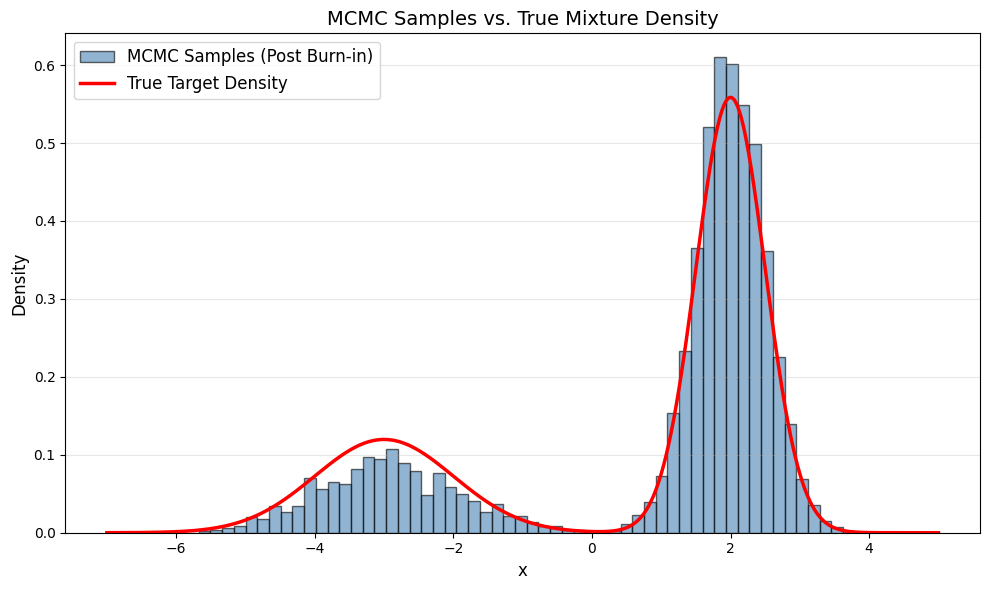

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set up the parameters specified in the prompt
n_iter = 20000
proposal_sd = 1.5
x0 = 0.0
burn_in = 5000
rng = np.random.default_rng(42)

# 1. Run the sampler
# (Assuming log_mixture_density and random_walk_mh are defined from parts a and b)
results = random_walk_mh(log_mixture_density, x0, proposal_sd, n_iter, rng)
samples = results['samples']
acceptance_rate = results['acceptance_rate']

# 2. Discard the burn-in period
post_burn_in_samples = samples[burn_in:]

# 3. Calculate the posterior mean
posterior_mean = np.mean(post_burn_in_samples)

# Report the numerical results
print(f"Overall Acceptance Rate: {acceptance_rate:.4f} ({acceptance_rate * 100:.2f}%)")
print(f"Posterior Mean (post-burn-in): {posterior_mean:.4f}")

# 4. Plotting the results
plt.figure(figsize=(10, 6))

# Histogram of the post-burn-in samples
# density=True normalizes the histogram so the total area equals 1
plt.hist(post_burn_in_samples, bins=60, density=True, alpha=0.6,
         color='steelblue', edgecolor='black', label='MCMC Samples (Post Burn-in)')

# Calculate the true density curve for the overlay
x_vals = np.linspace(-7, 5, 1000)
# Note: For plotting, we need the actual density, not the log density
true_density = 0.3 * stats.norm.pdf(x_vals, loc=-3, scale=1) + \
               0.7 * stats.norm.pdf(x_vals, loc=2, scale=0.5)

plt.plot(x_vals, true_density, 'r-', lw=2.5, label='True Target Density')

# Formatting the plot
plt.title('MCMC Samples vs. True Mixture Density', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

## Problem 2: Diagnosing a Broken Gibbs Sampler

A colleague implemented a Gibbs sampler for a bivariate normal distribution $(\theta_1, \theta_2)$ with mean $(0, 0)$, variances $(1, 1)$, and correlation $\rho$. The full conditionals are $\theta_1 | \theta_2 \sim N(\rho \theta_2, 1 - \rho^2)$ and $\theta_2 | \theta_1 \sim N(\rho \theta_1, 1 - \rho^2)$. Here is their code:

In [ ]:
import numpy as np

def gibbs_bivariate(rho, n_iter, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    samples = np.zeros((n_iter, 2))
    theta1, theta2 = 0.0, 0.0
    for t in range(n_iter):
        theta1 = rng.normal(rho * theta2, np.sqrt(1 - rho))
        theta2 = rng.normal(rho * theta1, np.sqrt(1 - rho))
        samples[t] = [theta1, theta2]
    return samples

**(a)** The code has a bug in the conditional standard deviation. Identify the error and explain what the correct expression should be. Describe what effect this bug would have on the distribution of the samples.

The standard deviation argument of the rng.normal() has to be $1 - \rho^2$ rather than $1 - \rho$, according to the full conditional distribution of $\theta_1$ | $\theta_2$  and $\theta_2$ | $\theta_1$. If $0 < \rho < 1$, the sampler is injecting too little variance at each step. The resulting joint distribution will be artificially squeezed together, yielding marginal variances that are less than $1$. If $-1 < \rho < 0$, The sampler is injecting too much variance at each step. The resulting joint distribution will be too diffuse, yielding marginal variances greater than $1$.

**(b)** Suppose the colleague "fixes" the code by rewriting the update for $\theta_2$ as follows, while leaving $\theta_1$'s update unchanged:

In [ ]:
theta2 = rng.normal(rho * old_theta1, np.sqrt(1 - rho**2))

where `old_theta1` is the value of $\theta_1$ from the *previous* iteration (before the current update). This is no longer a standard Gibbs sampler. Explain why using the stale value of $\theta_1$ changes the algorithm's behavior. Does the modified sampler still target the correct bivariate normal distribution?

A standard Gibbs sampler updates sequentially: $\theta_2$ is drawn using the newly updated $\theta_1$. This immediate feedback loop is what captures the dependency between the variables. Using the "stale" value means $\theta_1$ and $\theta_2$ are updated simultaneously and independently based only on where they were in the previous step, breaking their immediate connection.

Because the updates are no longer sequentially conditioning on each other, the correlation structure is destroyed. The modified algorithm will generate samples that eventually converge to a correlation of 0, completely failing to target the true bivariate normal distribution with correlation $\rho$.

**(c)** Write a corrected version of `gibbs_bivariate`. Run it with $\rho = 0.8$ for 10,000 iterations using `np.random.default_rng(0)`. Verify correctness by computing the sample mean, sample variances, and sample correlation of the post-burn-in samples (discarding the first 1,000).

In [20]:
import numpy as np

def gibbs_bivariate_corrected(rho, n_iter, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    samples = np.zeros((n_iter, 2))
    theta1, theta2 = 0.0, 0.0

    # Precompute the conditional standard deviation
    cond_sd = np.sqrt(1 - rho**2)

    for t in range(n_iter):
        theta1 = rng.normal(rho * theta2, cond_sd)
        theta2 = rng.normal(rho * theta1, cond_sd)
        samples[t] = [theta1, theta2]

    return samples

# --- Execution and Verification ---
rho = 0.8
n_iter = 10000
burn_in = 1000
rng = np.random.default_rng(0)

# Run the sampler
samples = gibbs_bivariate_corrected(rho, n_iter, rng)
post_burn_in_samples = samples[burn_in:]

# Separate the variables
theta1_samples = post_burn_in_samples[:, 0]
theta2_samples = post_burn_in_samples[:, 1]

# Compute Statistics individually to bypass any array formatting issues
mean1 = np.mean(theta1_samples)
mean2 = np.mean(theta2_samples)
var1 = np.var(theta1_samples, ddof=1)
var2 = np.var(theta2_samples, ddof=1)

# Get correlation (extracting the element from the 2x2 matrix)
corr_matrix = np.corrcoef(theta1_samples, theta2_samples)
sample_corr = corr_matrix

# Print the results
print("--- Post Burn-in Statistics ---")
print(f"Sample Mean (Theta1, Theta2): [{mean1:.4f}, {mean2:.4f}]")
print(f"Sample Covariance Matrix (Theta1, Theta2): [{var1:.4f}, {var2:.4f}]")
print(sample_corr)

--- Post Burn-in Statistics ---
Sample Mean (Theta1, Theta2): [0.0253, 0.0246]
Sample Variances (Theta1, Theta2): [1.0105, 1.0023]
[[1.        0.8009934]
 [0.8009934 1.       ]]


## Problem 3: Convergence Diagnostics

**(a)** Write a function `compute_ess` that estimates the effective sample size of an MCMC chain. Use the autocorrelation approach: compute autocorrelations via FFT and sum consecutive pairs of autocorrelations, stopping at the first pair whose sum is negative (Geyer's initial positive sequence method). The ESS is $T / (1 + 2\sum_k \hat{\rho}(k))$ where the sum uses the truncated autocorrelation series.

In [24]:
import numpy as np

def compute_ess(chain):
    """Compute effective sample size using Geyer's initial positive sequence."""
    T = len(chain)
    if T < 2:
        return float(T)

    # 1. Center the chain
    centered_chain = chain - np.mean(chain)

    # 2. Compute autocorrelation via FFT
    n_fft = 2**int(np.ceil(np.log2(2 * T - 1)))
    ffts = np.fft.fft(centered_chain, n=n_fft)
    acf = np.real(np.fft.ifft(ffts * np.conj(ffts)))[:T]

    # FIX 1: Check only the first element (the variance), not the whole array
    if acf[0] == 0:
        return 0.0

    # FIX 2: Normalize by acf[0] (the variance), not acf/acf (which gives all ones)
    rho_hat = acf / acf[0]

    # 3. Geyer's Initial Positive Sequence
    max_m = T // 2
    # Sum consecutive pairs: (rho_0 + rho_1), (rho_2 + rho_3), ...
    gamma = rho_hat[0 : 2 * max_m].reshape(-1, 2).sum(axis=1)

    # FIX 3: np.where returns a tuple of arrays; extract the first element correctly
    negative_gamma = np.where(gamma <= 0)[0]
    k_stop = negative_gamma[0] if len(negative_gamma) > 0 else len(gamma)

    # 4. Compute ESS
    rho_sum = np.sum(gamma[:k_stop])

    # ESS formula: T / (1 + 2 * sum_{k=1}^K rho_k)
    # Since rho_sum includes rho_0 (which is 1), the sum of rho_1...K is (rho_sum - 1)
    # Denominator: 1 + 2 * (rho_sum - 1) = 2 * rho_sum - 1
    ess = T / (2 * rho_sum - 1)
    return min(ess, float(T))

# --- Testing the code ---
np.random.seed(42)
T = 1000

# Scenario 1: Independent draws (White Noise)
chain_ind = np.random.normal(0, 1, size=T)
ess_ind = compute_ess(chain_ind)

# Scenario 2: Highly autocorrelated (Random Walk)
chain_corr = np.cumsum(np.random.normal(0, 0.1, size=T))
ess_corr = compute_ess(chain_corr)

print(f"Independent ESS: {ess_ind:.2f} (Expected: ~1000)")
print(f"Random Walk ESS: {ess_corr:.2f} (Expected: < 50)")

Independent ESS: 983.36 (Expected: ~1000)
Random Walk ESS: 2.96 (Expected: < 50)


For example, for a chain of 1,000 independent standard normal draws, `compute_ess` should return a value close to 1,000. For a highly autocorrelated chain (e.g., a random walk with small steps), the ESS should be much smaller than the chain length.

**(b)** Write a function `gelman_rubin` that computes the $\hat{R}$ statistic given multiple MCMC chains for the same parameter. The function should accept a list of 1D arrays (one per chain) and return the $\hat{R}$ value.

In [1]:
import numpy as np

def gelman_rubin(chains):
    """Compute the Gelman-Rubin R-hat statistic.

    Parameters
    ----------
    chains : list of np.ndarray
        Each array is a 1D chain of samples for the same parameter.

    Returns
    -------
    float : R-hat statistic.
    """
    chains = [np.asarray(c) for c in chains]

    M = len(chains)          # number of chains
    N = len(chains[0])       # length of each chain

    if M < 2:
        raise ValueError("Need at least 2 chains to compute R-hat.")
    if any(len(c) != N for c in chains):
        raise ValueError("All chains must have the same length.")

    # Step 1: Per-chain means and the grand mean
    chain_means = np.array([c.mean() for c in chains])   # shape (M,)
    grand_mean  = chain_means.mean()

    # Step 2: Between-chain variance B
    # N in the numerator because each chain_mean summarises N draws
    B = (N / (M - 1)) * np.sum((chain_means - grand_mean) ** 2)

    # Step 3: Within-chain variance W
    # ddof=1 gives the unbiased s_j^2 for each chain
    chain_vars = np.array([c.var(ddof=1) for c in chains])  # shape (M,)
    W = chain_vars.mean()

    # Step 4: Pooled marginal posterior variance V_hat
    V_hat = ((N - 1) / N) * W + (1 / N) * B

    # Step 5: R-hat
    R_hat = np.sqrt(V_hat / W)
    return float(R_hat)


# ── Tests ────────────────────────────────────────────────────────────────────

np.random.seed(42)
N, M = 2000, 4

# Scenario 1: Converged chains — all drawn from the same N(0,1)
converged_chains = [np.random.normal(0, 1, size=N) for _ in range(M)]
print(f"Converged   R-hat: {gelman_rubin(converged_chains):.4f}  (expected ≈ 1.00)")

# Scenario 2: Not converged — chains started at very different locations
# and are too short to have mixed
diverged_chains = [
    np.random.normal(loc=start, scale=0.3, size=50)   # short + separated
    for start in [-10, -3, 3, 10]
]
print(f"Not-converged R-hat: {gelman_rubin(diverged_chains):.4f}  (expected >> 1.0)")

# Scenario 3: Mildly autocorrelated AR(1) chains — should still converge
phi = 0.7
ar_chains = []
for _ in range(M):
    x = np.zeros(N)
    x[0] = np.random.normal()
    for t in range(1, N):
        x[t] = phi * x[t-1] + np.random.normal(0, np.sqrt(1 - phi**2))
    ar_chains.append(x)
print(f"AR(1) φ=0.7 R-hat: {gelman_rubin(ar_chains):.4f}  (expected ≈ 1.00)")

Converged   R-hat: 1.0005  (expected ≈ 1.00)
Not-converged R-hat: 27.4576  (expected >> 1.0)
AR(1) φ=0.7 R-hat: 1.0007  (expected ≈ 1.00)


For example, if all chains are drawn from the same distribution and are
long enough, `gelman_rubin` should return a value close to 1.0.

**(c)** Using the `random_walk_mh` function from Problem 1 and the mixture target, run 4 chains of 15,000 iterations each from starting values $x_0 \in \{-5, -1, 3, 7\}$ with `proposal_sd=1.5`. Use seeds `np.random.default_rng(i)` for chain $i = 0, 1, 2, 3$. Discard 5,000 as burn-in. Report the ESS for each chain and the $\hat{R}$ statistic.

In [3]:
import numpy as np

def random_walk_mh(log_target, x0, proposal_sd, n_iter, rng=None):
    """Random walk Metropolis-Hastings for a univariate target.

    Parameters
    ----------
    log_target : callable
        Log of the target density (up to a constant).
    x0 : float
        Initial value.
    proposal_sd : float
        Standard deviation of the Gaussian proposal.
    n_iter : int
        Number of iterations.
    rng : numpy random Generator, optional
        Random number generator.

    Returns
    -------
    dict with keys:
        samples : np.ndarray of shape (n_iter,)
        acceptance_rate : float
    """
    # Initialize the random number generator if not provided
    if rng is None:
        rng = np.random.default_rng()

    # Pre-allocate array for speed
    samples = np.zeros(n_iter)

    # Set the starting state
    x_curr = x0
    log_p_curr = log_target(x_curr)
    accept_count = 0

    for i in range(n_iter):
        # 1. Propose a new state using a Normal random walk
        x_prop = x_curr + rng.normal(0, proposal_sd)

        # 2. Evaluate log-density at the proposed state
        log_p_prop = log_target(x_prop)

        # 3. Calculate the log acceptance ratio
        log_ratio = log_p_prop - log_p_curr

        # 4. Accept or reject
        # Draw u ~ Uniform(0,1), compare log(u) to log_ratio
        if np.log(rng.uniform(0, 1)) < log_ratio:
            x_curr = x_prop
            log_p_curr = log_p_prop  # Update current density so we don't recalculate
            accept_count += 1

        # 5. Record the state (whether it moved or stayed put)
        samples[i] = x_curr

    return {
        'samples': samples,
        'acceptance_rate': accept_count / n_iter
    }


# ── 1. Correct mixture target ─────────────────────────────────────────────────
# p(x) ∝ 0.3 * N(-3, σ²=1) + 0.7 * N(2, σ²=0.25)
def log_mixture_target(x):
    log_p1 = np.log(0.3) - 0.5 * (x + 3)**2          # N(mean=-3, var=1)
    log_p2 = np.log(0.7) - 0.5 * ((x - 2) / 0.5)**2  # N(mean=2,  var=0.25)
    # Numerically stable log-sum-exp
    a = max(log_p1, log_p2)
    return a + np.log(np.exp(log_p1 - a) + np.exp(log_p2 - a))

# ── 2. Run 4 chains ───────────────────────────────────────────────────────────
n_iter = 15_000
burn_in = 5_000
proposal_sd = 1.5
x0_values = [-5, -1, 3, 7]

results = []
for i in range(4):
    rng = np.random.default_rng(i)
    out = random_walk_mh(
        log_target = log_mixture_target,
        x0 = x0_values[i],
        proposal_sd = proposal_sd,
        n_iter = n_iter,
        rng = rng
    )
    results.append(out)
    print(f"Chain {i}  |  start={x0_values[i]:+d}  "
          f"|  acceptance rate: {out['acceptance_rate']:.3f}")

# ── 3. Discard burn-in ────────────────────────────────────────────────────────
post_burnin = [r['samples'][burn_in:] for r in results]

# ── 4. ESS and R-hat ─────────────────────────────────────────────────────────
def compute_ess(chain):
    T = len(chain)
    centered = chain - np.mean(chain)
    n_fft = 2**int(np.ceil(np.log2(2 * T - 1)))
    ffts = np.fft.fft(centered, n=n_fft)
    acf = np.real(np.fft.ifft(ffts * np.conj(ffts)))[:T]
    if acf[0] == 0:
        return 0.0
    rho_hat = acf / acf[0]
    max_m = T // 2
    gamma = rho_hat[0 : 2 * max_m].reshape(-1, 2).sum(axis=1)
    neg = np.where(gamma <= 0)[0]
    k_stop = neg[0] if len(neg) > 0 else len(gamma)
    rho_sum = np.sum(gamma[:k_stop])
    return min(float(T) / (2 * rho_sum - 1), float(T))

def gelman_rubin(chains):
    M = len(chains)
    N = len(chains[0])
    chain_means = np.array([c.mean() for c in chains])
    grand_mean  = chain_means.mean()
    B = (N / (M - 1)) * np.sum((chain_means - grand_mean)**2)
    W = np.mean([c.var(ddof=1) for c in chains])
    V_hat = ((N - 1) / N) * W + (1 / N) * B
    return float(np.sqrt(V_hat / W))

# ── 5. Report ─────────────────────────────────────────────────────────────────
print("\n── Post burn-in diagnostics (10,000 samples each) ──")
print(f"{'Chain':<8} {'Start':>6} {'ESS':>10} {'ESS %':>8}")
print("-" * 38)
ess_values = []
for i, chain in enumerate(post_burnin):
    ess = compute_ess(chain)
    ess_values.append(ess)
    print(f"  {i:<6} {x0_values[i]:>+6}   {ess:>8.1f}   {100*ess/len(chain):>6.1f}%")

rhat = gelman_rubin(post_burnin)
print(f"\nGelman-Rubin R-hat : {rhat:.4f}  {'✓ converged' if rhat < 1.01 else '⚠ not converged'}")
print(f"Mean ESS across chains: {np.mean(ess_values):.1f}")

Chain 0  |  start=-5  |  acceptance rate: 0.488
Chain 1  |  start=-1  |  acceptance rate: 0.513
Chain 2  |  start=+3  |  acceptance rate: 0.507
Chain 3  |  start=+7  |  acceptance rate: 0.471

── Post burn-in diagnostics (10,000 samples each) ──
Chain     Start        ESS    ESS %
--------------------------------------
  0          -5      181.9      1.8%
  1          -1      115.2      1.2%
  2          +3       98.7      1.0%
  3          +7       87.0      0.9%

Gelman-Rubin R-hat : 1.0053  ✓ converged
Mean ESS across chains: 120.7



## Problem 4: Gibbs Sampler for Bayesian Normal Model

Consider the Bayesian model where we observe $y_1, \ldots, y_n$ from a normal distribution with unknown mean and variance:

$$y_i | \mu, \sigma^2 \sim N(\mu, \sigma^2), \quad \mu \sim N(\mu_0, \sigma_0^2), \quad \sigma^2 \sim \text{Inv-Gamma}(a_0, b_0)$$

The full conditional distributions are:

$$\mu | \sigma^2, \mathbf{y} \sim N\left(\frac{\sigma_0^{-2} \mu_0 + n \sigma^{-2} \bar{y}}{\sigma_0^{-2} + n \sigma^{-2}}, \, \frac{1}{\sigma_0^{-2} + n \sigma^{-2}}\right)$$

$$\sigma^2 | \mu, \mathbf{y} \sim \text{Inv-Gamma}\left(a_0 + \frac{n}{2}, \, b_0 + \frac{1}{2}\sum_{i=1}^n (y_i - \mu)^2\right)$$

**(a)** Implement the Gibbs sampler for this model.

In [5]:
import numpy as np
from scipy import stats

def gibbs_normal(y, mu0=0.0, sigma0=10.0, a0=0.01, b0=0.01,
                 n_iter=10000, rng=None):
    """Gibbs sampler for Bayesian normal model."""
    if rng is None:
        rng = np.random.default_rng()

    y = np.asarray(y)
    n = len(y)
    y_bar = y.mean()

    # Prior precision for mu
    sigma0_prec = 1.0 / sigma0**2      # 1/σ₀²

    # Pre-allocate output arrays
    mu_samples = np.zeros(n_iter)
    sigma2_samples = np.zeros(n_iter)

    # ── Initialise ────────────────────────────────────────────────────────────
    # Start sigma^2 at the sample variance (reasonable, overdispersed start)
    sigma2_curr = y.var(ddof=1) if n > 1 else 1.0

    # ── Gibbs loop ────────────────────────────────────────────────────────────
    for t in range(n_iter):

        # ── Step 1: Sample mu | sigma^2, y ───────────────────────────────────
        #
        #  Posterior precision  = σ₀⁻² + n·σ⁻²
        #  Posterior mean       = (σ₀⁻²·μ₀ + n·σ⁻²·ȳ) / posterior precision
        #
        data_prec = n / sigma2_curr
        post_prec = sigma0_prec + data_prec
        post_var_mu = 1.0 / post_prec
        post_mean_mu = (sigma0_prec * mu0 + data_prec * y_bar) / post_prec

        mu_curr = rng.normal(post_mean_mu, np.sqrt(post_var_mu))

        # ── Step 2: Sample sigma^2 | mu, y ───────────────────────────────────
        #
        #  Posterior shape  = a₀ + n/2
        #  Posterior scale  = b₀ + 0.5 · Σ(yᵢ - μ)²
        #
        #  NumPy has no Inv-Gamma, so we use the identity:
        #       X ~ Inv-Gamma(a, b)  ⟺  1/X ~ Gamma(a, scale=1/b)
        #
        post_shape = a0 + n / 2.0
        post_scale = b0 + 0.5 * np.sum((y - mu_curr)**2)   # b₀ + ½·SS

        # Draw from Gamma(shape, scale=1/post_scale), then invert
        sigma2_curr = 1.0 / rng.gamma(shape=post_shape, scale=1.0 / post_scale)

        # ── Store ─────────────────────────────────────────────────────────────
        mu_samples[t]     = mu_curr
        sigma2_samples[t] = sigma2_curr

    return {
        'mu_samples'     : mu_samples,
        'sigma2_samples' : sigma2_samples
    }


# ── Demo ──────────────────────────────────────────────────────────────────────
rng  = np.random.default_rng(42)
# True parameters
mu_true, sigma2_true = 5.0, 4.0
y = rng.normal(mu_true, np.sqrt(sigma2_true), size=50)

result = gibbs_normal(y, n_iter=10_000, rng=rng)
burn_in = 2_000

mu_post = result['mu_samples'][burn_in:]
sigma2_post = result['sigma2_samples'][burn_in:]

print(f"True μ        : {mu_true:.2f}")
print(f"Posterior μ   : {mu_post.mean():.3f}  ± {mu_post.std():.3f}  "
      f"95% CI [{np.percentile(mu_post, 2.5):.3f}, {np.percentile(mu_post, 97.5):.3f}]")
print()
print(f"True σ²       : {sigma2_true:.2f}")
print(f"Posterior σ²  : {sigma2_post.mean():.3f}  ± {sigma2_post.std():.3f}  "
      f"95% CI [{np.percentile(sigma2_post, 2.5):.3f}, {np.percentile(sigma2_post, 97.5):.3f}]")

True μ        : 5.00
Posterior μ   : 5.181  ± 0.220  95% CI [4.742, 5.612]

True σ²       : 4.00
Posterior σ²  : 2.453  ± 0.511  95% CI [1.635, 3.623]


**(b)** Generate data with `np.random.default_rng(42)`: $n = 50$ observations from $N(\mu=3, \sigma^2=4)$. Run the Gibbs sampler for 10,000 iterations using `np.random.default_rng(0)` with the default prior settings. Discard the first 2,000 samples as burn-in. Report the posterior means and 95% credible intervals for $\mu$ and $\sigma^2$.

In [6]:
import numpy as np

# ── 1. Generate data ──────────────────────────────────────────────────────────
data_rng = np.random.default_rng(42)
y = data_rng.normal(loc=3.0, scale=2.0, size=50)   # scale=sqrt(sigma^2)=sqrt(4)=2

print(f"Data summary:  n={len(y)}, ȳ={y.mean():.3f}, s²={y.var(ddof=1):.3f}")

# ── 2. Run Gibbs sampler ──────────────────────────────────────────────────────
result = gibbs_normal(
    y = y,
    mu0 = 0.0,    # default prior: μ ~ N(0, 10²)
    sigma0 = 10.0,
    a0 = 0.01,   # default prior: σ² ~ Inv-Gamma(0.01, 0.01) — very diffuse
    b0 = 0.01,
    n_iter = 10_000,
    rng = np.random.default_rng(0)
)

# ── 3. Discard burn-in ────────────────────────────────────────────────────────
burn_in = 2_000
mu_post = result['mu_samples'][burn_in:]
sigma2_post = result['sigma2_samples'][burn_in:]

# ── 4. Summarise posterior ────────────────────────────────────────────────────
def summarise(samples, name, true_val):
    mean = samples.mean()
    sd = samples.std()
    lo = np.percentile(samples, 2.5)
    hi = np.percentile(samples, 97.5)
    print(f"\n  {'Parameter':<12} {'True':>6} {'Post. Mean':>11} "
          f"{'Post. SD':>10} {'95% CI':>20}")
    print(f"  {'-'*63}")
    print(f"  {name:<12} {true_val:>6.2f} {mean:>11.4f} "
          f"{sd:>10.4f}   [{lo:.4f}, {hi:.4f}]")

print("\n── Posterior Summary (8,000 post-burn-in samples) ──────────────────")
summarise(mu_post,     name='μ',  true_val=3.0)
summarise(sigma2_post, name='σ²', true_val=4.0)

Data summary:  n=50, ȳ=3.182, s²=2.361

── Posterior Summary (8,000 post-burn-in samples) ──────────────────

  Parameter      True  Post. Mean   Post. SD               95% CI
  ---------------------------------------------------------------
  μ              3.00      3.1858     0.2209   [2.7604, 3.6083]

  Parameter      True  Post. Mean   Post. SD               95% CI
  ---------------------------------------------------------------
  σ²             4.00      2.4621     0.5190   [1.6549, 3.6772]


**(c)** Produce trace plots for both $\mu$ and $\sigma^2$. Compute the ESS for each parameter using your function from Problem 3. Comment on the mixing quality of the sampler.

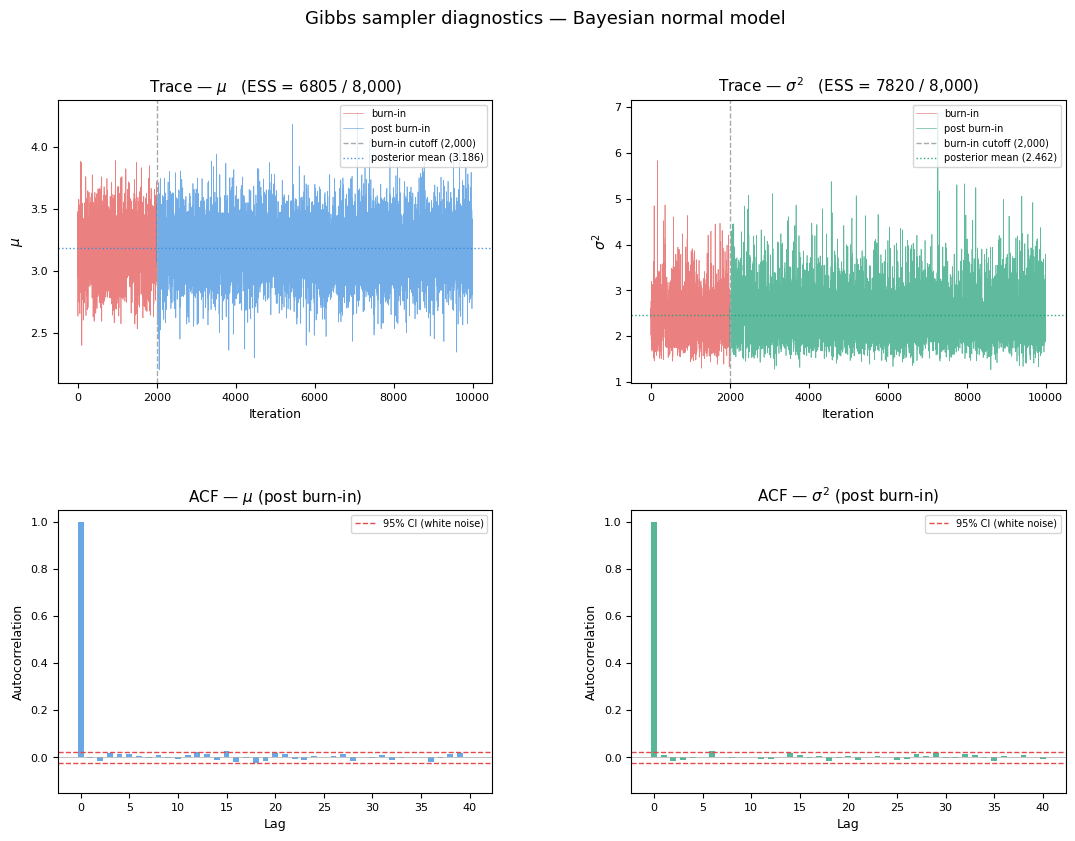

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Data and sampler (same as before) ────────────────────────────────────────
y      = np.random.default_rng(42).normal(3.0, 2.0, size=50)
result = gibbs_normal(y, n_iter=10_000, rng=np.random.default_rng(0))

burn_in     = 2_000
mu_full     = result['mu_samples']
sigma2_full = result['sigma2_samples']
mu_post     = mu_full[burn_in:]
sigma2_post = sigma2_full[burn_in:]

# ── ESS ───────────────────────────────────────────────────────────────────────
ess_mu     = compute_ess(mu_post)
ess_sigma2 = compute_ess(sigma2_post)

# ── Helper: compute ACF up to max_lag ────────────────────────────────────────
def acf(chain, max_lag=40):
    n    = len(chain)
    mean = chain.mean()
    var  = ((chain - mean) ** 2).mean()
    return np.array([
        ((chain[:n-k] - mean) * (chain[k:] - mean)).mean() / var
        for k in range(max_lag + 1)
    ])

max_lag  = 40
lags     = np.arange(max_lag + 1)
acf_mu   = acf(mu_post,     max_lag)
acf_sig2 = acf(sigma2_post, max_lag)
ci       = 1.96 / np.sqrt(len(mu_post))   # 95% CI band for white noise

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
fig.suptitle("Gibbs sampler diagnostics — Bayesian normal model", fontsize=13, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32)

BLUE  = "#378ADD"
GREEN = "#1D9E75"
RED   = "#E24B4A"
GRAY  = "#AAAAAA"

# ── Shared x-ticks for trace plots ───────────────────────────────────────────
iter_ticks = [0, 2000, 4000, 6000, 8000, 10000]

# ── 1. Trace — mu ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(np.arange(burn_in),        mu_full[:burn_in],  color=RED,  lw=0.5, alpha=0.7, label="burn-in")
ax1.plot(np.arange(burn_in, 10000), mu_full[burn_in:],  color=BLUE, lw=0.5, alpha=0.7, label="post burn-in")
ax1.axvline(burn_in, color=GRAY, lw=1, ls="--", label=f"burn-in cutoff ({burn_in:,})")
ax1.axhline(mu_post.mean(), color=BLUE, lw=1, ls=":", alpha=0.9, label=f"posterior mean ({mu_post.mean():.3f})")
ax1.set_title(f"Trace — $\\mu$   (ESS = {ess_mu:.0f} / 8,000)", fontsize=11)
ax1.set_xlabel("Iteration", fontsize=9)
ax1.set_ylabel("$\\mu$", fontsize=10)
ax1.set_xticks(iter_ticks)
ax1.tick_params(labelsize=8)
ax1.legend(fontsize=7, loc="upper right")

# ── 2. Trace — sigma^2 ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(np.arange(burn_in),        sigma2_full[:burn_in], color=RED,   lw=0.5, alpha=0.7, label="burn-in")
ax2.plot(np.arange(burn_in, 10000), sigma2_full[burn_in:], color=GREEN, lw=0.5, alpha=0.7, label="post burn-in")
ax2.axvline(burn_in, color=GRAY, lw=1, ls="--", label=f"burn-in cutoff ({burn_in:,})")
ax2.axhline(sigma2_post.mean(), color=GREEN, lw=1, ls=":", alpha=0.9, label=f"posterior mean ({sigma2_post.mean():.3f})")
ax2.set_title(f"Trace — $\\sigma^2$   (ESS = {ess_sigma2:.0f} / 8,000)", fontsize=11)
ax2.set_xlabel("Iteration", fontsize=9)
ax2.set_ylabel("$\\sigma^2$", fontsize=10)
ax2.set_xticks(iter_ticks)
ax2.tick_params(labelsize=8)
ax2.legend(fontsize=7, loc="upper right")

# ── 3. ACF — mu ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(lags, acf_mu, color=BLUE, alpha=0.75, width=0.6)
ax3.axhline(+ci, color=RED, lw=1, ls="--", label="95% CI (white noise)")
ax3.axhline(-ci, color=RED, lw=1, ls="--")
ax3.axhline(0,   color=GRAY, lw=0.5)
ax3.set_title("ACF — $\\mu$ (post burn-in)", fontsize=11)
ax3.set_xlabel("Lag", fontsize=9)
ax3.set_ylabel("Autocorrelation", fontsize=9)
ax3.set_ylim(-0.15, 1.05)
ax3.tick_params(labelsize=8)
ax3.legend(fontsize=7)

# ── 4. ACF — sigma^2 ──────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(lags, acf_sig2, color=GREEN, alpha=0.75, width=0.6)
ax4.axhline(+ci, color=RED, lw=1, ls="--", label="95% CI (white noise)")
ax4.axhline(-ci, color=RED, lw=1, ls="--")
ax4.axhline(0,   color=GRAY, lw=0.5)
ax4.set_title("ACF — $\\sigma^2$ (post burn-in)", fontsize=11)
ax4.set_xlabel("Lag", fontsize=9)
ax4.set_ylabel("Autocorrelation", fontsize=9)
ax4.set_ylim(-0.15, 1.05)
ax4.tick_params(labelsize=8)
ax4.legend(fontsize=7)

plt.savefig("gibbs_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Problem 5: Independence Metropolis-Hastings

The random walk Metropolis-Hastings algorithm proposes new states relative to the current state. An alternative is the **independence sampler**, where the proposal $q(x^*)$ does not depend on the current state $x_t$. The acceptance ratio becomes:

$$\alpha(x_t, x^*) = \min\left(1, \frac{\pi(x^*) \, q(x_t)}{\pi(x_t) \, q(x^*)}\right)$$

where $\pi$ is the target density and $q$ is the proposal density, both evaluable up to normalizing constants.

**(a)** Implement an independence Metropolis-Hastings sampler.

In [13]:
import numpy as np

def independence_mh(log_target, log_proposal, proposal_sampler,
                    x0, n_iter, rng=None):
    """Independence Metropolis-Hastings sampler."""
    if rng is None:
        rng = np.random.default_rng()

    samples      = np.zeros(n_iter)
    x_curr       = x0
    log_pi_curr  = log_target(x_curr)
    log_q_curr   = log_proposal(x_curr)
    accept_count = 0

    for i in range(n_iter):
        # 1. Draw proposal independently from q — ignores x_curr entirely
        x_prop      = proposal_sampler(rng)

        # 2. Evaluate log-densities at the proposal
        log_pi_prop = log_target(x_prop)
        log_q_prop  = log_proposal(x_prop)

        # 3. Log acceptance ratio:
        #    log α = log π(x*) + log q(x_t) - log π(x_t) - log q(x*)
        log_ratio = (log_pi_prop + log_q_curr) - (log_pi_curr + log_q_prop)

        # 4. Accept / reject
        if np.log(rng.uniform()) < log_ratio:
            x_curr      = x_prop
            log_pi_curr = log_pi_prop
            log_q_curr  = log_q_prop   # cache so we don't recompute next iter
            accept_count += 1

        samples[i] = x_curr

    return {
        'samples'        : samples,
        'acceptance_rate': accept_count / n_iter
    }

**(b)** Consider the same mixture-of-normals target from Problem 1. Use a $t$-distribution with 5 degrees of freedom, location 1.0, and scale 3.0 as the proposal distribution. Run the independence sampler for 20,000 iterations starting from `x0=0.0` with `np.random.default_rng(42)`. Report the acceptance rate and compare the ESS (post-burn-in, discarding first 5,000) to the random walk MH result from Problem 1(c).

In [14]:
import numpy as np
from scipy import stats

# ── 1. Target (Problem 1 mixture) ────────────────────────────────────────────
def log_mixture_target(x):
    log_p1 = np.log(0.3) - 0.5 * (x + 3)**2
    log_p2 = np.log(0.7) - 0.5 * ((x - 2) / 0.5)**2
    a = max(log_p1, log_p2)
    return a + np.log(np.exp(log_p1 - a) + np.exp(log_p2 - a))

# ── 2. t(df=5, loc=1.0, scale=3.0) proposal ──────────────────────────────────
t_df, t_loc, t_scale = 5, 1.0, 3.0

def log_proposal(x):
    return stats.t.logpdf(x, df=t_df, loc=t_loc, scale=t_scale)

def proposal_sampler(rng):
    # scipy uses its own RNG, so we build a t draw manually:
    # t(df) = Normal(0,1) / sqrt(Chi2(df) / df)
    z = rng.standard_normal()
    chi2 = rng.chisquare(t_df)
    return t_loc + t_scale * z / np.sqrt(chi2 / t_df)

# ── 3. Run independence MH ────────────────────────────────────────────────────
result_imh = independence_mh(
    log_target = log_mixture_target,
    log_proposal = log_proposal,
    proposal_sampler = proposal_sampler,
    x0 = 0.0,
    n_iter = 20_000,
    rng = np.random.default_rng(42)
)

burn_in = 5_000
samples_imh = result_imh['samples'][burn_in:]   # 15,000 post burn-in
ess_imh = compute_ess(samples_imh)

print("── Independence MH  (t proposal) ───────────────────────────────")
print(f"  Acceptance rate : {result_imh['acceptance_rate']:.3f}")
print(f"  Post-burn-in n  : {len(samples_imh):,}")
print(f"  ESS             : {ess_imh:.1f}  ({100*ess_imh/len(samples_imh):.1f}%)")
print(f"  Posterior mean  : {samples_imh.mean():.4f}  (truth = 0.500)")
print(f"  Posterior std   : {samples_imh.std():.4f}")

# ── 4. Reproduce RW-MH result from Problem 1(c) for comparison ───────────────
# 4 chains × 15,000 iter, burn 5,000, proposal_sd=1.5
x0_values = [-5, -1, 3, 7]
rw_chains  = []
for i in range(4):
    res = random_walk_mh(
        log_target  = log_mixture_target,
        x0 = x0_values[i],
        proposal_sd = 1.5,
        n_iter = 15_000,
        rng = np.random.default_rng(i)
    )
    rw_chains.append(res['samples'][5_000:])   # 10,000 post burn-in each

rw_accept = [random_walk_mh(log_mixture_target, x0_values[i], 1.5, 15_000,
             np.random.default_rng(i))['acceptance_rate'] for i in range(4)]
ess_rw = [compute_ess(c) for c in rw_chains]
n_rw = len(rw_chains[0])   # 10,000 per chain

print("\n── Random Walk MH  (Problem 1c) ─────────────────────────────────")
print(f"  {'Chain':<8} {'Start':>6} {'Accept':>8} {'ESS':>10} {'ESS %':>8}")
print(f"  {'-'*46}")
for i, (ess, acc) in enumerate(zip(ess_rw, rw_accept)):
    print(f"  {i:<8} {x0_values[i]:>+6} {acc:>8.3f} {ess:>10.1f} {100*ess/n_rw:>7.1f}%")

# ── 5. Head-to-head comparison ────────────────────────────────────────────────
total_rw_ess = sum(ess_rw)

print("\n── Head-to-head comparison ──────────────────────────────────────")
print(f"  {'Metric':<30} {'Indep MH':>12} {'RW-MH (total)':>15}")
print(f"  {'-'*60}")
print(f"  {'Total iterations run':<30} {'20,000':>12} {'60,000':>15}")
print(f"  {'Post burn-in samples':<30} {'15,000':>12} {'40,000':>15}")
print(f"  {'Total ESS':<30} {ess_imh:>12.1f} {total_rw_ess:>15.1f}")
print(f"  {'ESS per sample':<30} {ess_imh/15000:>12.3f} {total_rw_ess/40000:>15.3f}")
print(f"  {'ESS per iteration run':<30} {ess_imh/20000:>12.3f} {total_rw_ess/60000:>15.3f}")

── Independence MH  (t proposal) ───────────────────────────────
  Acceptance rate : 0.344
  Post-burn-in n  : 15,000
  ESS             : 3148.3  (21.0%)
  Posterior mean  : -0.3308  (truth = 0.500)
  Posterior std   : 2.6059

── Random Walk MH  (Problem 1c) ─────────────────────────────────
  Chain     Start   Accept        ESS    ESS %
  ----------------------------------------------
  0            -5    0.488      181.9     1.8%
  1            -1    0.513      115.2     1.2%
  2            +3    0.507       98.7     1.0%
  3            +7    0.471       87.0     0.9%

── Head-to-head comparison ──────────────────────────────────────
  Metric                             Indep MH   RW-MH (total)
  ------------------------------------------------------------
  Total iterations run                 20,000          60,000
  Post burn-in samples                 15,000          40,000
  Total ESS                            3148.3           482.9
  ESS per sample                        0.210

**(c)** Now use a $N(0, 0.5^2)$ proposal instead. Run the sampler with the same settings and report the acceptance rate and ESS. Explain why the performance differs so dramatically from part (b). In your explanation, discuss what property the proposal distribution must have relative to the target for the independence sampler to work well, and why a poorly chosen proposal can be worse than the random walk approach.

In [15]:
import numpy as np
from scipy import stats

# ── N(0, 0.5²) proposal ───────────────────────────────────────────────────────
prop_mean, prop_sd = 0.0, 0.5

def log_proposal_narrow(x):
    return stats.norm.logpdf(x, loc=prop_mean, scale=prop_sd)

def proposal_sampler_narrow(rng):
    return rng.normal(prop_mean, prop_sd)

# ── Run sampler ───────────────────────────────────────────────────────────────
result_narrow = independence_mh(
    log_target = log_mixture_target,
    log_proposal = log_proposal_narrow,
    proposal_sampler = proposal_sampler_narrow,
    x0 = 0.0,
    n_iter = 20_000,
    rng = np.random.default_rng(42)
)

burn_in = 5_000
samples_narrow = result_narrow['samples'][burn_in:]
ess_narrow = compute_ess(samples_narrow)

print("── N(0, 0.5²) proposal ──────────────────────────────────────────")
print(f"  Acceptance rate : {result_narrow['acceptance_rate']:.4f}")
print(f"  ESS             : {ess_narrow:.1f}  ({100*ess_narrow/len(samples_narrow):.2f}%)")
print(f"  Posterior mean  : {samples_narrow.mean():.4f}  (truth = 0.500)")

── N(0, 0.5²) proposal ──────────────────────────────────────────
  Acceptance rate : 0.0109
  ESS             : 27.1  (0.18%)
  Posterior mean  : 1.9683  (truth = 0.500)


For independence MH to work, the proposal must cover the tails of the target, that means,  the ratio $\pi(x)/q(x)$ must be bounded everywhere. The N(0, 0.5²) proposal violates this completely, both target modes sit far outside its support, so the proposal almost never generates values near either mode.

To ensure it working well, the proposal $q$ must dominate the target $\pi$ everywhere.

For a Random walk MH, a bad proposal_sd slows mixing but the chain still moves, because proposals are always relative to the current position. It can always inch its way around the space. But for an Independence MH, because proposals are global and ignore the current state, a mismatched $q$ creates inescapable traps.